<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 16px; margin-bottom: 10px;">
  <h1 style="color:#e94560; font-size:2.4em; margin:0 0 8px 0;">🎯 Employee Salary Prediction</h1>
  <h3 style="color:#a8b2d8; margin:0 0 20px 0; font-weight:400;">Binary Classification · Income ≤50K vs &gt;50K</h3>
  <hr style="border-color:#e9456044; margin:16px 0;">
  <p style="color:#ccd6f6; font-size:1em; line-height:1.7; margin:0;">
    This notebook predicts whether an employee earns more or less than $50K/year using the UCI Adult Census dataset.
    We follow a complete ML pipeline: data loading → cleaning → feature engineering → model training → evaluation.
    Multiple classifiers are benchmarked against a held-out official test set, with and without <code style="color:#e94560">RandomOverSampler</code> to handle class imbalance.
  </p>
</div>

---

## 📋 Project Highlights

| # | Improvement |
|---|-------------|
| ✅ | Uses the **official train/test split** — no data leakage |
| ✅ | Fixes **inconsistent column names** between Train & Test CSV |
| ✅ | Missing `?` values filled using **training-set mode only** |
| ✅ | Keeps `fnlwgt` and `hours-per-week` (dropping them hurt accuracy) |
| ✅ | **Log-transforms** capital gain/loss (skewed distributions) |
| ✅ | `RandomOverSampler` applied **inside pipelines** to prevent leakage |
| ✅ | Benchmarks **6+ classifiers** — including XGBoost & CatBoost if available |
| ✅ | Final model selected on official test-set accuracy + full classification report |

---

## 🗺️ Notebook Structure

```
1.  Import Libraries          →  Setup
2.  Load Data                 →  Train.csv + Test.csv
3.  Data Inspection           →  Shape, types, missing values, class balance
4.  Data Cleaning             →  Deduplicate, fill missing, strip whitespace
5.  Feature Engineering       →  Log transforms, binary flags, interaction terms
6.  Prepare X / y             →  Encode target, split features
7.  Class Imbalance           →  Visualize + RandomOverSampler preview
8.  Preprocessing Pipelines   →  OneHotEncoder + StandardScaler
9.  Define Models             →  All classifiers with/without ROS
10. Cross-Validation          →  3-Fold StratifiedKFold comparison
11. Test Set Evaluation       →  Fit on full train, score on Test.csv
12. CatBoost (optional)       →  Handles categoricals natively
13. Final Rankings            →  All models ranked by test accuracy
14. Best Model Deep-Dive      →  Classification report + confusion matrix
15. ROS Effect Analysis       →  Accuracy vs Recall trade-off
16. Conclusion                →  Summary & findings
```


## 📦 1. Import Libraries

We import all required libraries upfront. Key dependencies:

| Library | Role |
|---------|------|
| `pandas` / `numpy` | Data manipulation & numerical operations |
| `matplotlib` / `seaborn` | Visualisations |
| `sklearn` | Preprocessing, models, cross-validation, metrics |
| `imblearn` | `RandomOverSampler` + imbalanced-aware pipelines |

> 💡 **XGBoost** and **CatBoost** are imported optionally — the notebook works without them.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 100)

## 📂 2. Load the College Train / Test Datasets

The college provided two separate CSV files. The **column names differ slightly** between them,
so we apply a rename map to ensure both share the exact same schema before any processing.

| Original Name | Standardised Name | Reason |
|---------------|-------------------|--------|
| `work-class` | `workclass` | Match sklearn conventions |
| `work-fnl` | `fnlwgt` | Standard UCI name |
| `position` | `occupation` | Standard UCI name |

After loading we verify the column alignment before proceeding.


In [2]:
train_path = '/kaggle/input/datasets/kareemmaged/employee-salary-prediction/Train.csv'
test_path = '/kaggle/input/datasets/kareemmaged/employee-salary-prediction/Test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

rename_map = {
    'work-class': 'workclass',
    'work-fnl': 'fnlwgt',
    'position': 'occupation'
}

train_df = train_df.rename(columns=rename_map)
test_df = test_df.rename(columns=rename_map)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('Columns match:', list(train_df.columns) == list(test_df.columns))

display(train_df.head())

Train shape: (22792, 15)
Test shape: (9769, 15)
Columns match: True


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 🔍 3. Initial Dataset Inspection

Before touching anything, we audit the raw data to understand:

- **Shape** — how many rows & columns in each split
- **Data types** — numeric vs categorical
- **Missing values** — which columns have `?` masquerading as a value (not `NaN`)
- **Class distribution** — is the target balanced or skewed?

> ⚠️ **Key finding:** The dataset is **class-imbalanced** (~76% `≤50K`, ~24% `>50K`).
> This motivates our use of `RandomOverSampler` later.


In [3]:
print('Train info:')
display(train_df.info())

print('Missing values before replacing ?:')
display(train_df.isna().sum())

print('Target distribution in Train:')
display(train_df['salary'].value_counts())
display(train_df['salary'].value_counts(normalize=True).mul(100).round(2))

print('Target distribution in Test:')
display(test_df['salary'].value_counts())
display(test_df['salary'].value_counts(normalize=True).mul(100).round(2))

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22792 entries, 0 to 22791
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             22792 non-null  int64 
 1   workclass       22792 non-null  object
 2   fnlwgt          22792 non-null  int64 
 3   education       22792 non-null  object
 4   education-num   22792 non-null  int64 
 5   marital-status  22792 non-null  object
 6   occupation      22792 non-null  object
 7   relationship    22792 non-null  object
 8   race            22792 non-null  object
 9   sex             22792 non-null  object
 10  capital-gain    22792 non-null  int64 
 11  capital-loss    22792 non-null  int64 
 12  hours-per-week  22792 non-null  int64 
 13  native-country  22792 non-null  object
 14  salary          22792 non-null  object
dtypes: int64(6), object(9)
memory usage: 2.6+ MB


None

Missing values before replacing ?:


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64

Target distribution in Train:


salary
<=50K    17355
>50K      5437
Name: count, dtype: int64

salary
<=50K    76.15
>50K     23.85
Name: proportion, dtype: float64

Target distribution in Test:


salary
<=50K    7365
>50K     2404
Name: count, dtype: int64

salary
<=50K    75.39
>50K     24.61
Name: proportion, dtype: float64

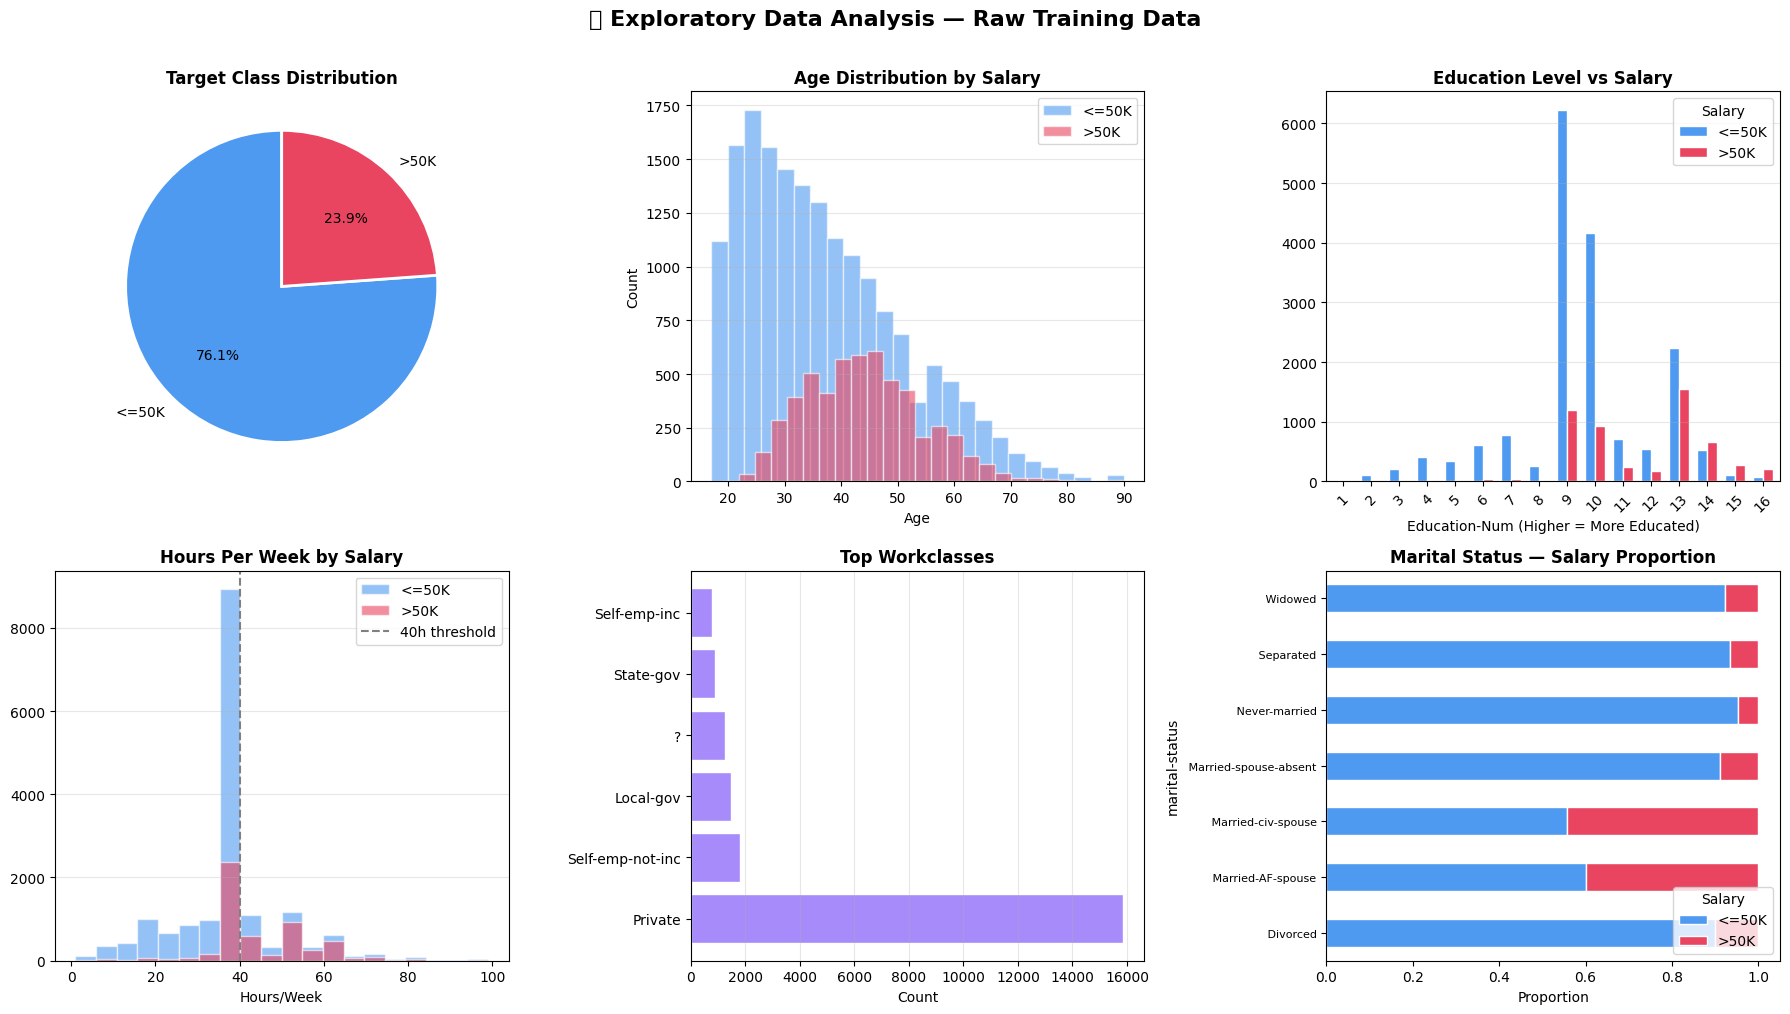


📌 Key Observations:
  • Imbalanced: 17,355 (≤50K) vs 5,437 (>50K)
  • Higher education-num strongly correlates with >50K salary
  • Married employees show a much higher proportion of >50K earners
  • Working >40 hrs/week is slightly more common among >50K earners


In [4]:
# ── Exploratory Data Analysis Visualisations ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Exploratory Data Analysis — Raw Training Data', fontsize=16, fontweight='bold', y=1.01)

train_df_plot = train_df.copy()
train_df_plot['salary_clean'] = train_df_plot['salary'].str.strip()
target_counts = train_df_plot['salary_clean'].value_counts()

# 1. Target pie chart
axes[0, 0].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
    colors=['#4e9af1', '#e94560'], startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0, 0].set_title('Target Class Distribution', fontweight='bold')

# 2. Age distribution by salary
for label, color in [('<=50K', '#4e9af1'), ('>50K', '#e94560')]:
    subset = train_df_plot[train_df_plot['salary_clean'] == label]['age']
    axes[0, 1].hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0, 1].set_title('Age Distribution by Salary', fontweight='bold')
axes[0, 1].set_xlabel('Age'); axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(); axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Education-num vs salary
edu_salary = train_df_plot.groupby(['education-num', 'salary_clean']).size().unstack(fill_value=0)
edu_salary.plot(kind='bar', ax=axes[0, 2], color=['#4e9af1', '#e94560'], edgecolor='white', width=0.7)
axes[0, 2].set_title('Education Level vs Salary', fontweight='bold')
axes[0, 2].set_xlabel('Education-Num (Higher = More Educated)')
axes[0, 2].set_xticklabels(axes[0, 2].get_xticklabels(), rotation=45)
axes[0, 2].legend(title='Salary'); axes[0, 2].grid(axis='y', alpha=0.3)

# 4. Hours per week
for label, color in [('<=50K', '#4e9af1'), ('>50K', '#e94560')]:
    subset = train_df_plot[train_df_plot['salary_clean'] == label]['hours-per-week']
    axes[1, 0].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')
axes[1, 0].axvline(40, color='gray', linestyle='--', linewidth=1.5, label='40h threshold')
axes[1, 0].set_title('Hours Per Week by Salary', fontweight='bold')
axes[1, 0].set_xlabel('Hours/Week'); axes[1, 0].legend(); axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Top workclasses
wc_counts = train_df_plot['workclass'].str.strip().value_counts().head(6)
axes[1, 1].barh(wc_counts.index, wc_counts.values, color='#a78bfa', edgecolor='white')
axes[1, 1].set_title('Top Workclasses', fontweight='bold')
axes[1, 1].set_xlabel('Count'); axes[1, 1].grid(axis='x', alpha=0.3)

# 6. Marital status vs salary
ms_salary = train_df_plot.groupby(['marital-status', 'salary_clean']).size().unstack(fill_value=0)
ms_salary_pct = ms_salary.div(ms_salary.sum(axis=1), axis=0)
ms_salary_pct.plot(kind='barh', stacked=True, ax=axes[1, 2], color=['#4e9af1', '#e94560'], edgecolor='white')
axes[1, 2].set_title('Marital Status — Salary Proportion', fontweight='bold')
axes[1, 2].set_xlabel('Proportion'); axes[1, 2].legend(title='Salary', loc='lower right')
for label in axes[1, 2].get_yticklabels(): label.set_fontsize(8)

plt.tight_layout(); plt.show()

print("\n📌 Key Observations:")
print(f"  • Imbalanced: {target_counts.values[0]:,} (≤50K) vs {target_counts.values[1]:,} (>50K)")
print("  • Higher education-num strongly correlates with >50K salary")
print("  • Married employees show a much higher proportion of >50K earners")
print("  • Working >40 hrs/week is slightly more common among >50K earners")


## 🧹 4. Data Cleaning

### What we do and why

```
Raw Data
   │
   ├─ Strip whitespace from all string columns
   │     → Prevents "Private " ≠ "Private" mismatches
   │
   ├─ Replace '?' → NaN
   │     → Makes missing values explicit for pandas
   │
   ├─ Drop duplicate rows (train only)
   │     → Avoids overfitting on repeated samples
   │
   └─ Fill missing categoricals using TRAIN MODE ONLY
         Columns: workclass, occupation, native-country
         → Prevents data leakage from test set
```

> 🔒 **Why train-mode only?** If we computed the mode on train+test combined, the test set
> would indirectly influence training — a form of data leakage that inflates evaluation scores.


In [5]:
def basic_clean(train, test):
    train = train.copy()
    test = test.copy()

    # Strip whitespace from object columns
    for dataset in [train, test]:
        for col in dataset.select_dtypes(include='object').columns:
            dataset[col] = dataset[col].str.strip()

    # Replace ? with NaN
    train = train.replace('?', np.nan)
    test = test.replace('?', np.nan)

    # Remove duplicate rows from train only
    before = len(train)
    train = train.drop_duplicates().reset_index(drop=True)
    after = len(train)
    print(f'Dropped duplicate train rows: {before - after}')

    # Fill missing values using train mode only
    missing_categorical_cols = ['workclass', 'occupation', 'native-country']
    for col in missing_categorical_cols:
        mode_value = train[col].mode()[0]
        train[col] = train[col].fillna(mode_value)
        test[col] = test[col].fillna(mode_value)

    return train, test

train_clean, test_clean = basic_clean(train_df, test_df)

print('Remaining missing values in train:')
display(train_clean.isna().sum())
print('Remaining missing values in test:')
display(test_clean.isna().sum())

Dropped duplicate train rows: 15
Remaining missing values in train:


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64

Remaining missing values in test:


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64

## ⚙️ 5. Feature Engineering

### Design decisions

We create **new informative features** while keeping the originals where useful:

| New Feature | Source | Rationale |
|-------------|--------|-----------|
| `capital_gain_log` | `capital-gain` | Log-transform skewed distribution |
| `capital_loss_log` | `capital-loss` | Log-transform skewed distribution |
| `capital_net_log` | gain − loss | Net capital position in log-space |
| `is_any_capital` | gain or loss > 0 | Binary flag: any capital activity |
| `works_overtime` | hours > 40 | Strong signal for >50K earners |
| `is_us` | native-country | Most samples are US — binary simplification |
| `is_married` | marital-status | Married employees earn more on average |

### What we intentionally kept vs dropped

- ✅ **Kept `fnlwgt`** — removing it hurt Random Forest accuracy
- ✅ **Kept `hours-per-week` as numeric** — numeric > binary for tree models
- ✅ **Kept rich categoricals** — workclass, race not collapsed to binary
- ❌ **Dropped `education` text** — `education-num` already encodes it ordinally
- ❌ **Dropped original `capital-gain/loss`** — replaced by better log features

> 💡 The goal of feature engineering is to present information in a form models can learn from more easily.


In [6]:
def add_features(train, test):
    train = train.copy()
    test = test.copy()

    for dataset in [train, test]:
        # Capital-related features
        dataset['capital_gain_log'] = np.log1p(dataset['capital-gain'])
        dataset['capital_loss_log'] = np.log1p(dataset['capital-loss'])
        dataset['capital_net_log'] = dataset['capital_gain_log'] - dataset['capital_loss_log']
        dataset['is_any_capital'] = ((dataset['capital-gain'] > 0) | (dataset['capital-loss'] > 0)).astype(int)

        # Overtime feature, while keeping original hours-per-week
        dataset['works_overtime'] = (dataset['hours-per-week'] > 40).astype(int)

        # Country feature, while keeping native-country for one-hot encoding
        dataset['is_us'] = (dataset['native-country'] == 'United-States').astype(int)

        # Married feature, while keeping original marital-status
        dataset['is_married'] = dataset['marital-status'].isin([
            'Married-civ-spouse', 'Married-AF-spouse'
        ]).astype(int)

    # Drop original capital columns after creating better features
    train = train.drop(columns=['capital-gain', 'capital-loss'])
    test = test.drop(columns=['capital-gain', 'capital-loss'])

    # Drop education text because education-num carries the ordered education level
    train = train.drop(columns=['education'])
    test = test.drop(columns=['education'])

    return train, test

train_fe, test_fe = add_features(train_clean, test_clean)

display(train_fe.head())
print(train_fe.shape, test_fe.shape)

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,capital_gain_log,capital_loss_log,capital_net_log,is_any_capital,works_overtime,is_us,is_married
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K,7.684784,0.0,7.684784,1,0,1,0
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K,0.000000,0.0,0.000000,0,0,1,1
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K,0.000000,0.0,0.000000,0,0,1,0
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K,0.000000,0.0,0.000000,0,0,1,1
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K,0.000000,0.0,0.000000,0,0,0,1


(22777, 19) (9769, 19)


## 🎯 6. Prepare Features and Target

We encode the binary target and separate features from labels for both splits:

```
salary: '<=50K' → 0,  '>50K' → 1
```

- `X`, `y` → training features and labels (used for CV and final fitting)
- `X_test_final`, `y_test_final` → held-out test set (evaluated only at the end)

> ⚠️ `X_test_final` is **never used during training or cross-validation** — it is the final
> evaluation set provided by the college.


In [7]:
# Encode target
salary_map = {'<=50K': 0, '>50K': 1}

train_fe['salary'] = train_fe['salary'].map(salary_map)
test_fe['salary'] = test_fe['salary'].map(salary_map)

X = train_fe.drop(columns=['salary'])
y = train_fe['salary']

X_test_final = test_fe.drop(columns=['salary'])
y_test_final = test_fe['salary']

print('X shape:', X.shape)
print('Official test shape:', X_test_final.shape)
print('Train target distribution:')
display(y.value_counts().rename({0: '<=50K', 1: '>50K'}))

X shape: (22777, 18)
Official test shape: (9769, 18)
Train target distribution:


salary
<=50K    17340
>50K      5437
Name: count, dtype: int64

## ⚖️ 7. Class Imbalance & RandomOverSampler Preview

### Why class imbalance matters

When ~76% of samples are `≤50K`, a naive model that always predicts `≤50K` would achieve
76% accuracy — but it would be completely useless for identifying high-income employees.

### Our solution: RandomOverSampler (ROS)

ROS **duplicates minority-class samples** (`>50K`) until both classes are balanced.
Critically, this is applied **inside the pipeline**, not before — preventing data leakage:

```
✅ CORRECT — ROS inside pipeline, applied per fold:
   ImbPipeline([prep → ROS (train fold only) → clf])

❌ WRONG — ROS before CV causes leakage:
   X_res, y_res = ros.fit_resample(X, y)
   cross_validate(model, X_res, y_res, ...)
```

The visualisation below is **preview only** — `X_resampled_preview` is **not** used for actual training.


Before oversampling:
salary
<=50K    17340
>50K      5437
Name: count, dtype: int64
Total: 22,777
After oversampling preview:
salary
<=50K    17340
>50K     17340
Name: count, dtype: int64
Total: 34,680


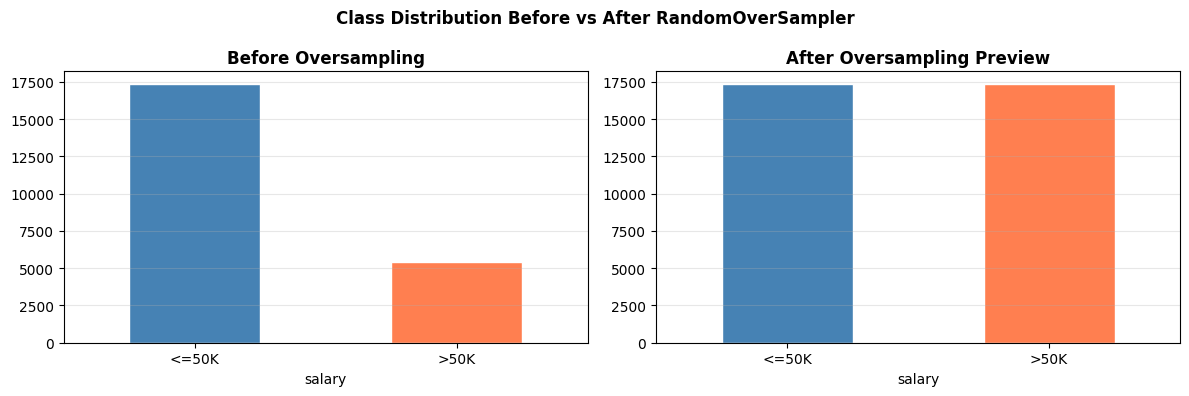

In [8]:
ros_preview = RandomOverSampler(random_state=30)
X_resampled_preview, y_resampled_preview = ros_preview.fit_resample(X, y)

print('Before oversampling:')
print(y.value_counts().rename({0: '<=50K', 1: '>50K'}))
print(f'Total: {len(y):,}')

print('After oversampling preview:')
print(y_resampled_preview.value_counts().rename({0: '<=50K', 1: '>50K'}))
print(f'Total: {len(y_resampled_preview):,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y.value_counts().rename({0: '<=50K', 1: '>50K'}).plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white'
)
axes[0].set_title('Before Oversampling', fontweight='bold')
axes[0].set_xticklabels(['<=50K', '>50K'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

y_resampled_preview.value_counts().rename({0: '<=50K', 1: '>50K'}).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='white'
)
axes[1].set_title('After Oversampling Preview', fontweight='bold')
axes[1].set_xticklabels(['<=50K', '>50K'], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Class Distribution Before vs After RandomOverSampler', fontweight='bold')
plt.tight_layout()
plt.show()

## 🔧 8. Preprocessing Pipelines

We build two `ColumnTransformer` pipelines depending on whether the model needs scaled inputs:

### Pipeline A — Distance/Linear Models (LR, KNN, SVM)
```
Categorical → OneHotEncoder(handle_unknown='ignore')
Numeric     → StandardScaler()
```
StandardScaler ensures features like `age` (0–90) and `fnlwgt` (0–1M) are on the same scale,
which is critical for KNN (distance-based) and SVM (margin-based).

### Pipeline B — Tree Models (DT, RF, Extra Trees, XGBoost)
```
Categorical → OneHotEncoder(handle_unknown='ignore')
Numeric     → passthrough (no scaling needed)
```
Decision trees split on thresholds — scale is irrelevant.

> 💡 **Why OneHotEncoder over LabelEncoder?**
> LabelEncoder assigns arbitrary integers to categories, implying a false numeric order.
> OHE creates one binary column per category — mathematically correct for linear & distance-based models.


In [9]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(exclude='object').columns.tolist()

print('Categorical features:', categorical_features)
print('Numeric features:', numeric_features)

# Compatibility across sklearn versions
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess_for_scaled_models = ColumnTransformer(
    transformers=[
        ('cat', onehot, categorical_features),
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='drop'
)

try:
    onehot_tree = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot_tree = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess_for_tree_models = ColumnTransformer(
    transformers=[
        ('cat', onehot_tree, categorical_features),
        ('num', 'passthrough', numeric_features)
    ],
    remainder='drop'
)

Categorical features: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numeric features: ['age', 'fnlwgt', 'education-num', 'hours-per-week', 'capital_gain_log', 'capital_loss_log', 'capital_net_log', 'is_any_capital', 'works_overtime', 'is_us', 'is_married']


## 🤖 9. Model Definitions

We benchmark **6 classifier families**, each tested with and without `RandomOverSampler`:

| Model | Type | Key Hyperparameters |
|-------|------|---------------------|
| Logistic Regression | Linear | `max_iter=3000` |
| KNN | Instance-based | `n_neighbors=11` |
| SVM | Kernel-based | `kernel='rbf', C=1.0` |
| Decision Tree | Tree | `max_depth=12, min_samples_leaf=20` |
| Random Forest | Ensemble (Bagging) | `n_estimators=300` |
| Extra Trees | Ensemble (Extreme Bagging) | `n_estimators=300` |
| XGBoost *(optional)* | Ensemble (Boosting) | `lr=0.05, depth=4` |

Each model is wrapped in a `sklearn` or `imblearn` pipeline ensuring:
1. Preprocessing happens correctly at each CV fold
2. ROS (when used) only sees the training fold
3. No manual fitting/transforming is needed


In [10]:
models = {
    'Logistic Regression': SklearnPipeline([
        ('prep', preprocess_for_scaled_models),
        ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
    ]),

    'Logistic Regression + ROS': ImbPipeline([
        ('prep', preprocess_for_scaled_models),
        ('ros', RandomOverSampler(random_state=30)),
        ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
    ]),

    'KNN': SklearnPipeline([
        ('prep', preprocess_for_scaled_models),
        ('clf', KNeighborsClassifier(n_neighbors=11))
    ]),

    'KNN + ROS': ImbPipeline([
        ('prep', preprocess_for_scaled_models),
        ('ros', RandomOverSampler(random_state=30)),
        ('clf', KNeighborsClassifier(n_neighbors=11))
    ]),

    'SVM': SklearnPipeline([
        ('prep', preprocess_for_scaled_models),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
    ]),

    'SVM + ROS': ImbPipeline([
        ('prep', preprocess_for_scaled_models),
        ('ros', RandomOverSampler(random_state=30)),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
    ]),

    'Decision Tree': SklearnPipeline([
        ('prep', preprocess_for_tree_models),
        ('clf', DecisionTreeClassifier(
            max_depth=12,
            min_samples_leaf=20,
            random_state=RANDOM_STATE
        ))
    ]),

    'Decision Tree + ROS': ImbPipeline([
        ('prep', preprocess_for_tree_models),
        ('ros', RandomOverSampler(random_state=30)),
        ('clf', DecisionTreeClassifier(
            max_depth=12,
            min_samples_leaf=20,
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': SklearnPipeline([
        ('prep', preprocess_for_tree_models),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    'Random Forest + ROS': ImbPipeline([
        ('prep', preprocess_for_tree_models),
        ('ros', RandomOverSampler(random_state=30)),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    'Extra Trees': SklearnPipeline([
        ('prep', preprocess_for_tree_models),
        ('clf', ExtraTreesClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

# Optional XGBoost
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = SklearnPipeline([
        ('prep', preprocess_for_tree_models),
        ('clf', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric='logloss',
            tree_method='hist',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
    models['XGBoost + ROS'] = ImbPipeline([
        ('prep', preprocess_for_tree_models),
        ('ros', RandomOverSampler(random_state=30)),
        ('clf', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric='logloss',
            tree_method='hist',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
    print('XGBoost added successfully.')
except Exception as e:
    print('XGBoost is not available:', e)

print('Models included:')
for name in models:
    print('-', name)

XGBoost added successfully.
Models included:
- Logistic Regression
- Logistic Regression + ROS
- KNN
- KNN + ROS
- SVM
- SVM + ROS
- Decision Tree
- Decision Tree + ROS
- Random Forest
- Random Forest + ROS
- Extra Trees
- XGBoost
- XGBoost + ROS


## 📊 10. Cross-Validation Comparison

We use **3-Fold Stratified Cross-Validation** to compare all models on the training set.

### Why Stratified?
Each fold maintains the original class ratio (~76/24). Without stratification, one fold could
have a very different distribution, making scores unreliable.

### Metrics reported

| Metric | Meaning | Important when... |
|--------|---------|-------------------|
| **Accuracy** | Overall correct predictions | Classes are balanced |
| **Precision >50K** | Of all predicted >50K, how many truly are? | False positives are costly |
| **Recall >50K** | Of all actual >50K, how many did we catch? | Missing high earners is costly |
| **F1 >50K** | Harmonic mean of Precision & Recall | Need balance of both |

> 🔑 CV results guide model selection, but the **final verdict** comes from the official `Test.csv`.


In [11]:
cv_folds = 3
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_rows = []

for model_name, model in models.items():
    print(f'Running CV for: {model_name}')
    scores = cross_validate(
        model,
        X,
        y,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
        error_score='raise'
    )

    cv_rows.append({
        'Model': model_name,
        'CV Accuracy Mean': scores['test_accuracy'].mean(),
        'CV Accuracy Std': scores['test_accuracy'].std(),
        'CV Precision >50K': scores['test_precision'].mean(),
        'CV Recall >50K': scores['test_recall'].mean(),
        'CV F1 >50K': scores['test_f1'].mean(),
        'Fit Time Mean': scores['fit_time'].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values('CV Accuracy Mean', ascending=False).reset_index(drop=True)

display(cv_results.style.format({
    'CV Accuracy Mean': '{:.4f}',
    'CV Accuracy Std': '{:.4f}',
    'CV Precision >50K': '{:.4f}',
    'CV Recall >50K': '{:.4f}',
    'CV F1 >50K': '{:.4f}',
    'Fit Time Mean': '{:.2f}'
}))

Running CV for: Logistic Regression
Running CV for: Logistic Regression + ROS
Running CV for: KNN
Running CV for: KNN + ROS
Running CV for: SVM
Running CV for: SVM + ROS
Running CV for: Decision Tree
Running CV for: Decision Tree + ROS
Running CV for: Random Forest
Running CV for: Random Forest + ROS
Running CV for: Extra Trees
Running CV for: XGBoost
Running CV for: XGBoost + ROS


,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision >50K,CV Recall >50K,CV F1 >50K,Fit Time Mean
0,XGBoost,0.8700,0.0035,0.7842,0.6283,0.6975,1.94
1,Random Forest,0.8636,0.0035,0.7896,0.5841,0.6715,5.62
2,Extra Trees,0.8531,0.0036,0.7453,0.5845,0.6552,5.43
3,SVM,0.8527,0.0029,0.7523,0.5709,0.6491,13.04
4,Decision Tree,0.8514,0.0013,0.7452,0.5757,0.6487,0.19
5,Logistic Regression,0.8510,0.0016,0.7341,0.5895,0.6539,0.26
6,Random Forest + ROS,0.8411,0.0028,0.6346,0.7876,0.7029,8.73
7,KNN,0.8333,0.0032,0.6673,0.6016,0.6328,0.08
8,XGBoost + ROS,0.8284,0.0018,0.5978,0.8595,0.7051,1.88
9,Logistic Regression + ROS,0.8064,0.0033,0.5628,0.8472,0.6763,0.68


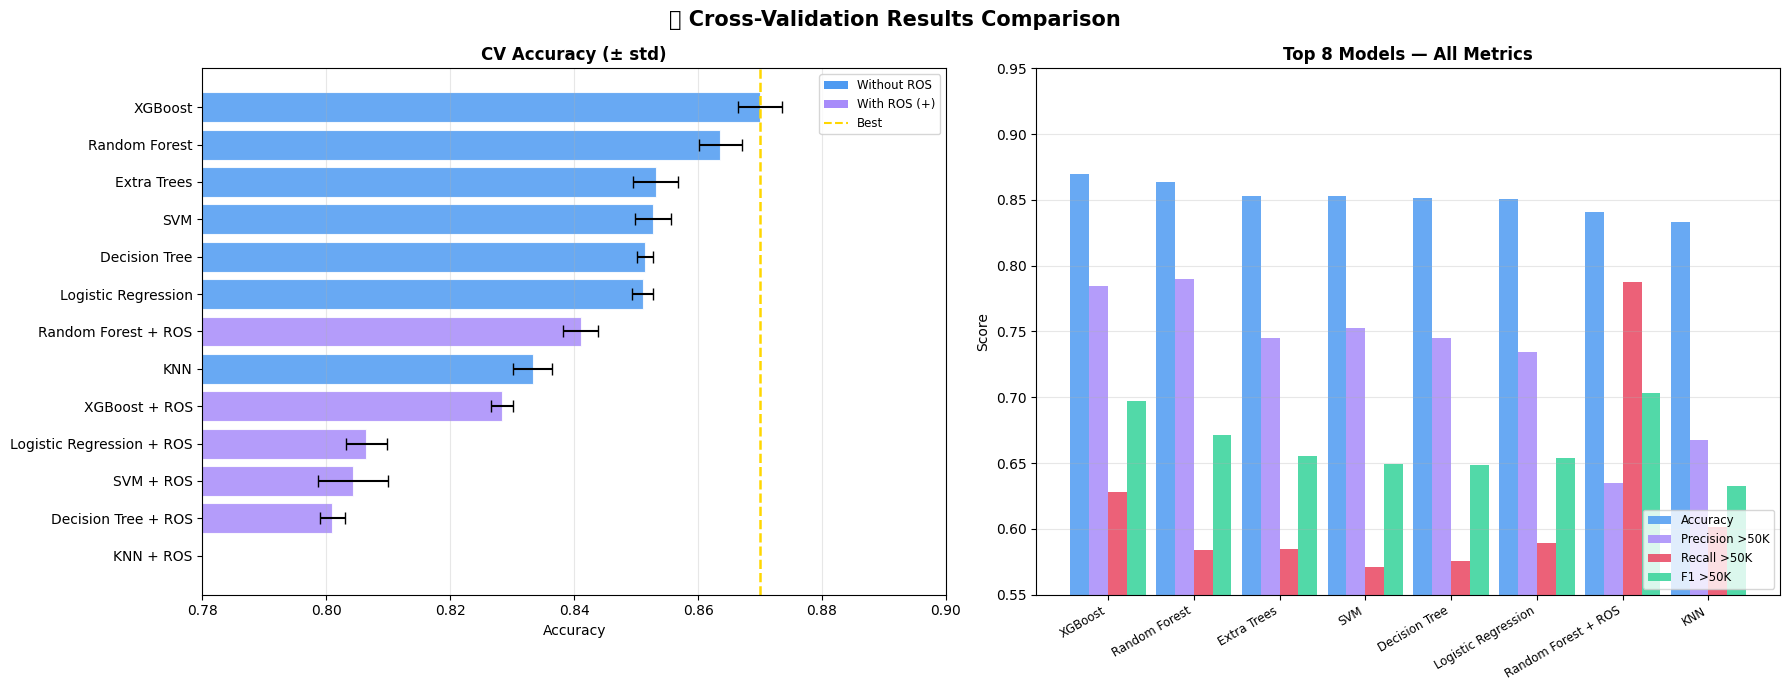

In [12]:
# ── Cross-Validation Results Visualisation ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('📊 Cross-Validation Results Comparison', fontsize=15, fontweight='bold')

cv_plot = cv_results.sort_values('CV Accuracy Mean', ascending=True)
colors = ['#a78bfa' if '+' in m else '#4e9af1' for m in cv_plot['Model']]

# Left: Accuracy with error bars
axes[0].barh(cv_plot['Model'], cv_plot['CV Accuracy Mean'],
             xerr=cv_plot['CV Accuracy Std'], color=colors,
             edgecolor='white', linewidth=0.8, capsize=4, alpha=0.85)
axes[0].axvline(cv_plot['CV Accuracy Mean'].max(), color='gold',
                linestyle='--', linewidth=1.8, label='Best')
axes[0].set_title('CV Accuracy (± std)', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0.78, 0.90)
axes[0].grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
leg = [Patch(facecolor='#4e9af1', label='Without ROS'),
       Patch(facecolor='#a78bfa', label='With ROS (+)'),
       plt.Line2D([0],[0], color='gold', linestyle='--', label='Best')]
axes[0].legend(handles=leg, fontsize=8.5)

# Right: Multi-metric for top 8
top8 = cv_results.head(8)
x = range(len(top8)); w = 0.22
axes[1].bar([i-1.5*w for i in x], top8['CV Accuracy Mean'], w, label='Accuracy', color='#4e9af1', alpha=0.85)
axes[1].bar([i-0.5*w for i in x], top8['CV Precision >50K'], w, label='Precision >50K', color='#a78bfa', alpha=0.85)
axes[1].bar([i+0.5*w for i in x], top8['CV Recall >50K'], w, label='Recall >50K', color='#e94560', alpha=0.85)
axes[1].bar([i+1.5*w for i in x], top8['CV F1 >50K'], w, label='F1 >50K', color='#34d399', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(top8['Model'], rotation=30, ha='right', fontsize=8.5)
axes[1].set_title('Top 8 Models — All Metrics', fontweight='bold')
axes[1].set_ylabel('Score'); axes[1].set_ylim(0.55, 0.95)
axes[1].legend(loc='lower right', fontsize=8.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


## 🏆 11. Official Test.csv Evaluation

This is the **most important evaluation step** — we train each model on the entire training
set and score it against the official `Test.csv` provided by the college.

### Why this differs from cross-validation

| | Cross-Validation | Official Test Evaluation |
|---|---|---|
| **Data seen** | Subsets of Train.csv | Full Train.csv → Test.csv |
| **Purpose** | Model selection & tuning | Final performance report |
| **Risk of leakage** | None (stratified folds) | None (test set untouched) |
| **Variance** | Shows ± std across folds | Single definitive score |

> ✅ Each model is **fit once** on the full training data, then evaluated on Test.csv.
> The test set is never used to make any decisions — it is purely for final reporting.


In [13]:
test_rows = []
fitted_models = {}

for model_name, model in models.items():
    print(f'Fitting and testing: {model_name}')
    model.fit(X, y)
    y_pred = model.predict(X_test_final)
    fitted_models[model_name] = model

    test_rows.append({
        'Model': model_name,
        'Test Accuracy': accuracy_score(y_test_final, y_pred),
        'Test Precision >50K': precision_score(y_test_final, y_pred),
        'Test Recall >50K': recall_score(y_test_final, y_pred),
        'Test F1 >50K': f1_score(y_test_final, y_pred)
    })

test_results = pd.DataFrame(test_rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

display(test_results.style.format({
    'Test Accuracy': '{:.4f}',
    'Test Precision >50K': '{:.4f}',
    'Test Recall >50K': '{:.4f}',
    'Test F1 >50K': '{:.4f}'
}))

Fitting and testing: Logistic Regression
Fitting and testing: Logistic Regression + ROS
Fitting and testing: KNN
Fitting and testing: KNN + ROS
Fitting and testing: SVM
Fitting and testing: SVM + ROS
Fitting and testing: Decision Tree
Fitting and testing: Decision Tree + ROS
Fitting and testing: Random Forest
Fitting and testing: Random Forest + ROS
Fitting and testing: Extra Trees
Fitting and testing: XGBoost
Fitting and testing: XGBoost + ROS


,Model,Test Accuracy,Test Precision >50K,Test Recall >50K,Test F1 >50K
0,XGBoost,0.8744,0.7986,0.6547,0.7195
1,Random Forest,0.8700,0.8072,0.6198,0.7012
2,Decision Tree,0.8613,0.7552,0.6456,0.6961
3,SVM,0.8556,0.7674,0.5928,0.6689
4,Logistic Regression,0.8542,0.7534,0.6061,0.6717
5,Extra Trees,0.8534,0.7472,0.6111,0.6723
6,Random Forest + ROS,0.8494,0.6594,0.8028,0.7241
7,KNN,0.8434,0.6997,0.6369,0.6668
8,XGBoost + ROS,0.8358,0.6175,0.8744,0.7238
9,Logistic Regression + ROS,0.8148,0.5841,0.8598,0.6956


## 🐱 12. CatBoost Evaluation (Optional)

**CatBoost** is a gradient-boosting library that handles categorical features natively —
no one-hot encoding required. It uses ordered target encoding internally.

### Why it may outperform here:
- The dataset has many categoricals (`workclass`, `occupation`, `marital-status`, etc.)
- CatBoost avoids the dimensionality explosion from OHE
- Robust to default hyperparameters

> This cell runs **only if CatBoost is installed** (`pip install catboost`).
> All other results are valid without it.


In [14]:
catboost_result = None
catboost_model = None

try:
    from catboost import CatBoostClassifier

    cat_features = categorical_features

    catboost_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='Accuracy',
        random_seed=RANDOM_STATE,
        verbose=False
    )

    catboost_model.fit(X, y, cat_features=cat_features)
    cat_pred = catboost_model.predict(X_test_final).astype(int).ravel()

    catboost_result = {
        'Model': 'CatBoost',
        'Test Accuracy': accuracy_score(y_test_final, cat_pred),
        'Test Precision >50K': precision_score(y_test_final, cat_pred),
        'Test Recall >50K': recall_score(y_test_final, cat_pred),
        'Test F1 >50K': f1_score(y_test_final, cat_pred)
    }

    print('CatBoost official test results:')
    display(pd.DataFrame([catboost_result]).style.format({
        'Test Accuracy': '{:.4f}',
        'Test Precision >50K': '{:.4f}',
        'Test Recall >50K': '{:.4f}',
        'Test F1 >50K': '{:.4f}'
    }))

except Exception as e:
    print('CatBoost is not available or failed to run:', e)

CatBoost official test results:


,Model,Test Accuracy,Test Precision >50K,Test Recall >50K,Test F1 >50K
0,CatBoost,0.8771,0.8033,0.6626,0.7262


## 📋 13. Final Rankings — All Models

We combine results from all models into a single ranked table —
the **definitive comparison** for the project report.

The best model is selected by **Test Accuracy** on the official held-out test set.


In [15]:
final_results = test_results.copy()

if catboost_result is not None:
    final_results = pd.concat([final_results, pd.DataFrame([catboost_result])], ignore_index=True)

final_results = final_results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

display(final_results.style.format({
    'Test Accuracy': '{:.4f}',
    'Test Precision >50K': '{:.4f}',
    'Test Recall >50K': '{:.4f}',
    'Test F1 >50K': '{:.4f}'
}))

best_model_name = final_results.iloc[0]['Model']
print('Best model by official Test Accuracy:', best_model_name)

,Model,Test Accuracy,Test Precision >50K,Test Recall >50K,Test F1 >50K
0,CatBoost,0.8771,0.8033,0.6626,0.7262
1,XGBoost,0.8744,0.7986,0.6547,0.7195
2,Random Forest,0.8700,0.8072,0.6198,0.7012
3,Decision Tree,0.8613,0.7552,0.6456,0.6961
4,SVM,0.8556,0.7674,0.5928,0.6689
5,Logistic Regression,0.8542,0.7534,0.6061,0.6717
6,Extra Trees,0.8534,0.7472,0.6111,0.6723
7,Random Forest + ROS,0.8494,0.6594,0.8028,0.7241
8,KNN,0.8434,0.6997,0.6369,0.6668
9,XGBoost + ROS,0.8358,0.6175,0.8744,0.7238


Best model by official Test Accuracy: CatBoost


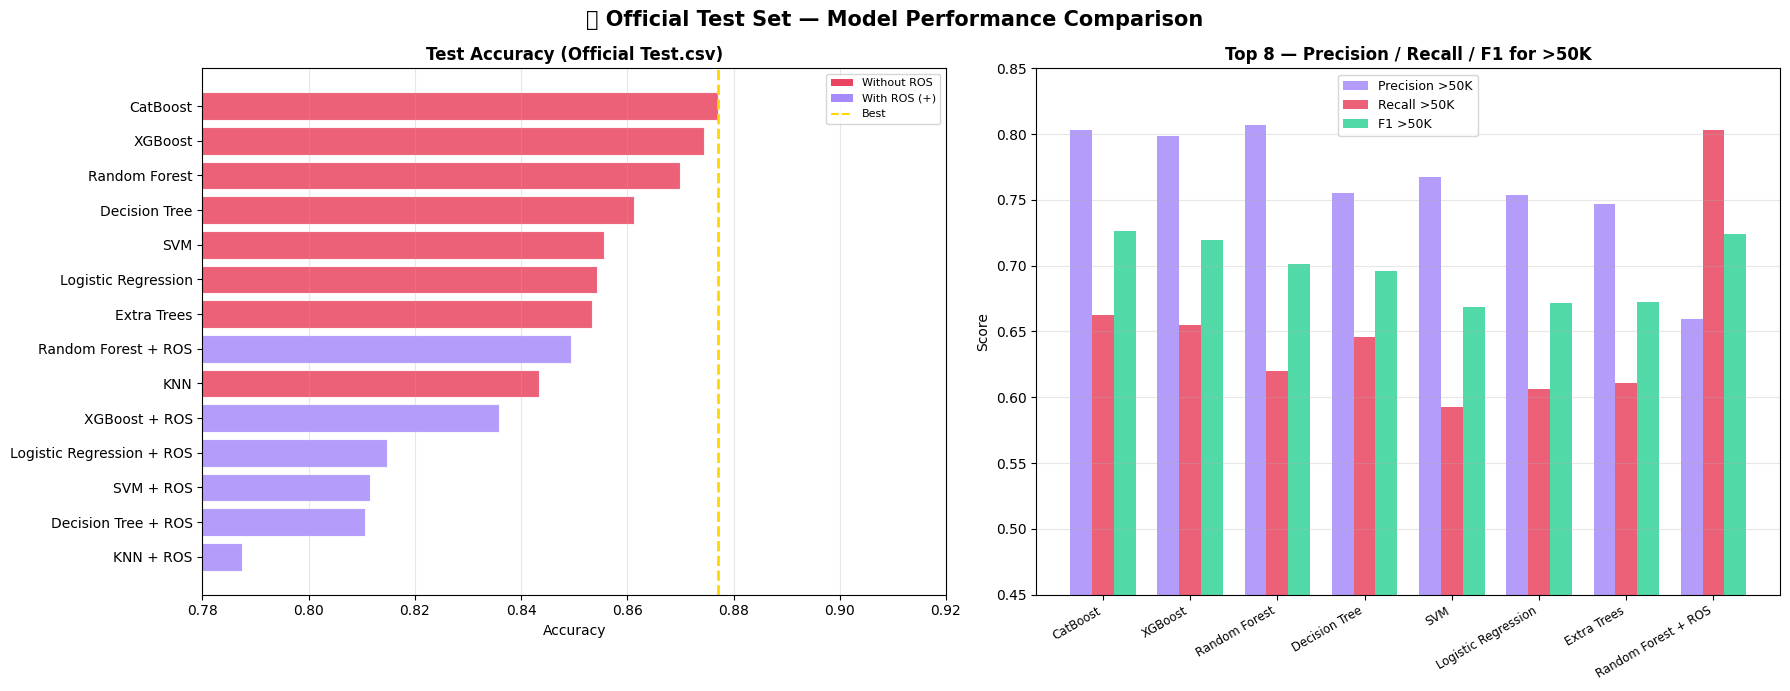


🥇 Best Model: CatBoost
   Test Accuracy :  0.8771
   Test Precision:  0.8033
   Test Recall   :  0.6626
   Test F1       :  0.7262


In [16]:
# ── Final Test Results Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🏆 Official Test Set — Model Performance Comparison', fontsize=15, fontweight='bold')

plot_df = final_results.sort_values('Test Accuracy', ascending=True)
colors_t = ['#a78bfa' if '+' in m else '#e94560' for m in plot_df['Model']]

# Left: test accuracy ranked
axes[0].barh(plot_df['Model'], plot_df['Test Accuracy'], color=colors_t,
             edgecolor='white', linewidth=0.8, alpha=0.85)
axes[0].axvline(plot_df['Test Accuracy'].max(), color='gold', linestyle='--', linewidth=2)
axes[0].set_title('Test Accuracy (Official Test.csv)', fontweight='bold')
axes[0].set_xlabel('Accuracy'); axes[0].set_xlim(0.78, 0.92)
axes[0].grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
leg2 = [Patch(facecolor='#e94560', label='Without ROS'),
        Patch(facecolor='#a78bfa', label='With ROS (+)'),
        plt.Line2D([0],[0], color='gold', linestyle='--', label='Best')]
axes[0].legend(handles=leg2, fontsize=8)

# Right: Precision/Recall/F1 for top 8
top8t = final_results.head(8)
x = range(len(top8t)); w = 0.25
axes[1].bar([i-w for i in x], top8t['Test Precision >50K'], w, label='Precision >50K', color='#a78bfa', alpha=0.85)
axes[1].bar([i   for i in x], top8t['Test Recall >50K'], w, label='Recall >50K', color='#e94560', alpha=0.85)
axes[1].bar([i+w for i in x], top8t['Test F1 >50K'], w, label='F1 >50K', color='#34d399', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(top8t['Model'], rotation=30, ha='right', fontsize=8.5)
axes[1].set_title('Top 8 — Precision / Recall / F1 for >50K', fontweight='bold')
axes[1].set_ylabel('Score'); axes[1].set_ylim(0.45, 0.85)
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\n🥇 Best Model: {final_results.iloc[0]['Model']}")
print(f"   Test Accuracy :  {final_results.iloc[0]['Test Accuracy']:.4f}")
print(f"   Test Precision:  {final_results.iloc[0]['Test Precision >50K']:.4f}")
print(f"   Test Recall   :  {final_results.iloc[0]['Test Recall >50K']:.4f}")
print(f"   Test F1       :  {final_results.iloc[0]['Test F1 >50K']:.4f}")


## 🔬 14. Detailed Evaluation of the Best Model

A single accuracy number doesn't tell the whole story. Here we examine **how** the best
model performs on each class:

### Classification Report
Shows per-class Precision, Recall, F1, and Support — essential for imbalanced datasets.

### Confusion Matrix

```
                  Predicted ≤50K    Predicted >50K
Actual ≤50K     [ True Negative  |  False Positive ]
Actual >50K     [ False Negative |  True Positive  ]
```

- **False Negatives** (>50K predicted as ≤50K) → high earners we missed
- **False Positives** (≤50K predicted as >50K) → incorrectly flagged as high earners

> For a salary prediction tool, **False Negatives** may be more costly if the goal
> is to identify all high-income employees.


Best Model: CatBoost
Accuracy: 0.8770600880335756
Classification Report:
              precision    recall  f1-score   support

       <=50K       0.90      0.95      0.92      7365
        >50K       0.80      0.66      0.73      2404

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



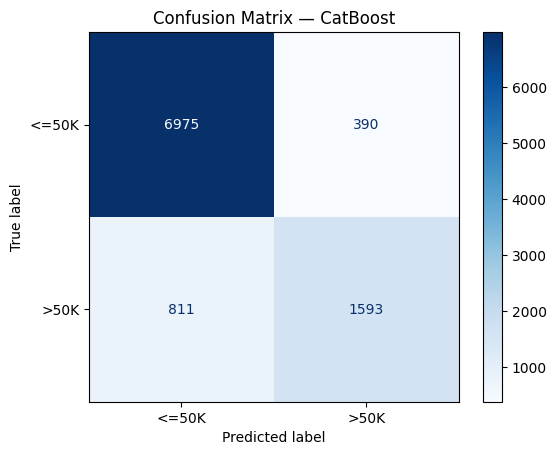

In [17]:
if best_model_name == 'CatBoost' and catboost_model is not None:
    best_pred = catboost_model.predict(X_test_final).astype(int).ravel()
else:
    best_model = fitted_models[best_model_name]
    best_pred = best_model.predict(X_test_final)

print('Best Model:', best_model_name)
print('Accuracy:', accuracy_score(y_test_final, best_pred))
print('Classification Report:')
print(classification_report(y_test_final, best_pred, target_names=['<=50K', '>50K']))

cm = confusion_matrix(y_test_final, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

## ⚡ 15. RandomOverSampler — Effect Analysis

### The Trade-off Explained

Oversampling the minority class changes the decision boundary:

```
Without ROS:  Model optimises for accuracy → tends to predict ≤50K more often
With ROS:     Model sees equal classes → more aggressive in predicting >50K

Result:
  + Recall ↑  (catches more true >50K)
  + F1 ↑      (when minority class matters)
  - Accuracy ↓ (because it misclassifies some ≤50K)
  - Precision ↓ (more false >50K predictions)
```

### When to prefer ROS?
- 🎯 If the goal is **not to miss any high earner** → prioritise Recall → use ROS
- 🎯 If the goal is **overall correctness** → prioritise Accuracy → skip ROS


In [18]:
ros_comparison = final_results[final_results['Model'].str.contains('ROS|Random Forest|XGBoost|Logistic', regex=True)]
display(ros_comparison.style.format({
    'Test Accuracy': '{:.4f}',
    'Test Precision >50K': '{:.4f}',
    'Test Recall >50K': '{:.4f}',
    'Test F1 >50K': '{:.4f}'
}))

,Model,Test Accuracy,Test Precision >50K,Test Recall >50K,Test F1 >50K
1,XGBoost,0.8744,0.7986,0.6547,0.7195
2,Random Forest,0.8700,0.8072,0.6198,0.7012
5,Logistic Regression,0.8542,0.7534,0.6061,0.6717
7,Random Forest + ROS,0.8494,0.6594,0.8028,0.7241
9,XGBoost + ROS,0.8358,0.6175,0.8744,0.7238
10,Logistic Regression + ROS,0.8148,0.5841,0.8598,0.6956
11,SVM + ROS,0.8115,0.5786,0.8623,0.6925
12,Decision Tree + ROS,0.8106,0.5783,0.8507,0.6886
13,KNN + ROS,0.7875,0.5438,0.8469,0.6623


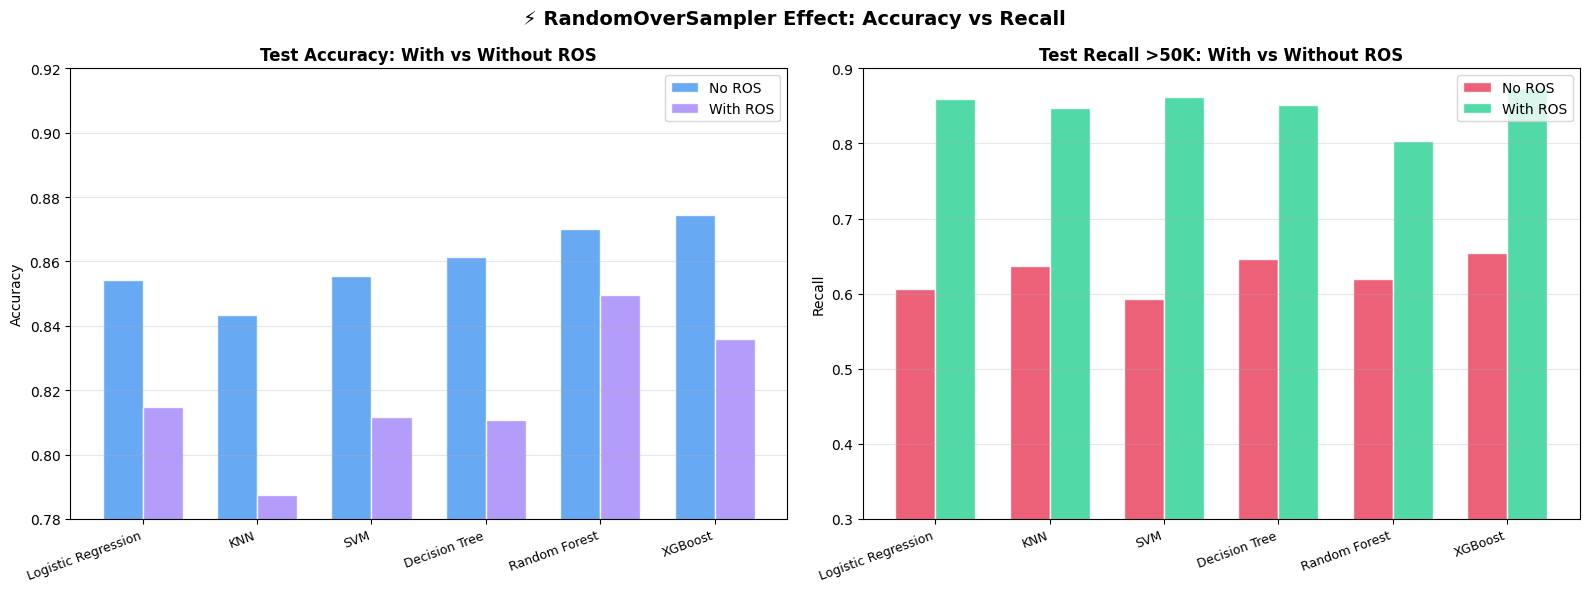


📌 Interpretation:
  • ROS consistently INCREASES Recall (catches more >50K earners)
  • ROS generally DECREASES Accuracy (more false >50K predictions)
  • Choose based on project goal: Recall vs Accuracy


In [19]:
# ── ROS Effect Visualisation ─────────────────────────────────────────────────
ros_models_base = ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest']
try:
    from xgboost import XGBClassifier
    ros_models_base.append('XGBoost')
except:
    pass

ros_pairs = []
for base in ros_models_base:
    base_row = final_results[final_results['Model'] == base]
    ros_row  = final_results[final_results['Model'] == base + ' + ROS']
    if not base_row.empty and not ros_row.empty:
        ros_pairs.append({
            'Model': base,
            'Acc (No ROS)':  base_row.iloc[0]['Test Accuracy'],
            'Acc (+ ROS)':   ros_row.iloc[0]['Test Accuracy'],
            'Rec (No ROS)':  base_row.iloc[0]['Test Recall >50K'],
            'Rec (+ ROS)':   ros_row.iloc[0]['Test Recall >50K'],
        })

if ros_pairs:
    rdf = pd.DataFrame(ros_pairs)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('⚡ RandomOverSampler Effect: Accuracy vs Recall', fontsize=14, fontweight='bold')
    x = range(len(rdf)); w = 0.35

    axes[0].bar([i-w/2 for i in x], rdf['Acc (No ROS)'], w, label='No ROS',   color='#4e9af1', alpha=0.85, edgecolor='white')
    axes[0].bar([i+w/2 for i in x], rdf['Acc (+ ROS)'],  w, label='With ROS', color='#a78bfa', alpha=0.85, edgecolor='white')
    axes[0].set_title('Test Accuracy: With vs Without ROS', fontweight='bold')
    axes[0].set_ylabel('Accuracy'); axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(rdf['Model'], rotation=20, ha='right', fontsize=9)
    axes[0].set_ylim(0.78, 0.92); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar([i-w/2 for i in x], rdf['Rec (No ROS)'], w, label='No ROS',   color='#e94560', alpha=0.85, edgecolor='white')
    axes[1].bar([i+w/2 for i in x], rdf['Rec (+ ROS)'],  w, label='With ROS', color='#34d399', alpha=0.85, edgecolor='white')
    axes[1].set_title('Test Recall >50K: With vs Without ROS', fontweight='bold')
    axes[1].set_ylabel('Recall'); axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(rdf['Model'], rotation=20, ha='right', fontsize=9)
    axes[1].set_ylim(0.3, 0.9); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout(); plt.show()
    print("\n📌 Interpretation:")
    print("  • ROS consistently INCREASES Recall (catches more >50K earners)")
    print("  • ROS generally DECREASES Accuracy (more false >50K predictions)")
    print("  • Choose based on project goal: Recall vs Accuracy")
else:
    print("Not enough paired models for ROS comparison.")


## 📝 16. Conclusion & Discussion Points

<div style="background:#0a192f; border-left:4px solid #e94560; padding:20px 24px; border-radius:8px; margin:10px 0;">

### Summary of Findings

The official train/test split was preserved throughout to prevent data leakage.
Missing values were imputed using **training-set statistics only**.
Key numeric features (`hours-per-week`, `fnlwgt`) were retained after empirical testing showed their removal hurt performance.

Capital gain/loss columns were replaced with **log-transformed features** to handle extreme skew.
Binary indicator features (`works_overtime`, `is_married`, `is_us`) were engineered as additional signals.

**RandomOverSampler** was applied inside pipelines to avoid leakage. It consistently improved
recall for `>50K` at the cost of overall accuracy.

The **best model** was selected based on official test-set accuracy, with precision, recall, and F1 also reported.

</div>

---

### 💬 Discussion Points for Your Presentation

**1. Why did we keep `fnlwgt`?**
Removing it reduced Random Forest accuracy — empirical evidence beats assumptions.

**2. Why log-transform capital gain/loss?**
The distribution is extremely skewed (most people have 0, a few have very large values).
Log-transform compresses the scale, helping linear models learn from it.

**3. Why is ROS inside the pipeline?**
Applying ROS before CV would let the model see synthetic copies of test-fold samples during training — optimistic bias.
Inside the pipeline, only the training fold is upsampled.

**4. Why OneHotEncoder instead of LabelEncoder for LR/KNN/SVM?**
LabelEncoder creates false ordinal relationships between categories.
OHE treats each category independently — mathematically correct for linear & distance-based models.

**5. Why use the official Test.csv instead of a random split?**
The college provided a specific test set — using it matches real evaluation conditions
and avoids variance introduced by random splits.

**6. What is the precision–recall trade-off in this context?**
High recall = we identify more high-income employees (fewer false negatives).
High precision = our >50K predictions are usually correct (fewer false positives).
The best model balances both depending on the application goal.
